(np.float64(-0.5), np.float64(217.5), np.float64(388.5), np.float64(-0.5))

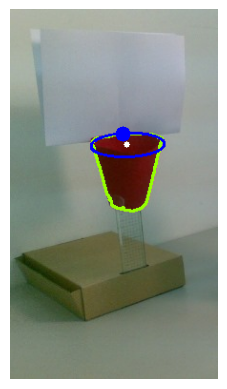

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/WhatsApp Image 2026-04-08 at 9.25.12 PM.jpeg"
img = cv2.imread(image_path)

img1 = img.copy()
lower_red = np.array([0, 0, 50])
upper_red = np.array([50, 50, 255])

mask = cv2.inRange(img, lower_red, upper_red)

_, thresh = cv2.threshold(mask, 127, 255, 0)

contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)


cnt = max(contours, key=cv2.contourArea)

cv2.drawContours(img1, [cnt], -1, (0,255,150), 2)





extLeft = tuple(cnt[cnt[:, :, 0].argmin()][0])
extRight = tuple(cnt[cnt[:, :, 0].argmax()][0])
extTop = tuple(cnt[cnt[:, :, 1].argmin()][0])



cv2.circle(img1, extTop, 8, (255, 0, 0), -1)

top_y = extTop[1]
rim_h = 20

rim_mask = mask[top_y-10 : top_y + rim_h,
                extLeft[0]-10 : extRight[0]+10]

rim_contours, _ = cv2.findContours(rim_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

rim_cnt = max(rim_contours, key=cv2.contourArea)

rim_cnt[:, 0, 0] += extLeft[0] - 10
rim_cnt[:, 0, 1] += top_y - 10

ellipse = cv2.fitEllipse(rim_cnt)

(center_x, center_y), (axes_major, axes_minor), angle = ellipse


cv2.circle(img1, (int(center_x), int(center_y)), 3, (255,255,255), -1)

cv2.ellipse(img1, ellipse, (255,0,0), 2)

img_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')